# Stroke Risk Prediction – Modeling

## Introduction

Stroke is one of the leading causes of death and disability worldwide. Early identification of high-risk patients can improve preventive care and reduce mortality. In this project, we use machine learning models to predict stroke risk based on patient demographic, clinical, and lifestyle factors.

The objectives of this study are:

* Identify key risk factors associated with stroke.
* Address class imbalance using SMOTE.
* Compare multiple machine learning models.
* Evaluate model performance using ROC AUC and recall.
* Interpret model outputs to support healthcare decision-making.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier


d:\Aleena\Git\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("../data/stroke_cleaned.csv")
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


# Splitting the features and target


In [4]:
X = df.drop("stroke", axis=1)
y = df["stroke"]

# Identify categorical columns

In [5]:
categorical_cols = X.select_dtypes(include="object").columns

C:\Users\DELL\AppData\Local\Temp\ipykernel_12268\3963226579.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include="object").columns


# One-hot encode

In [6]:
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Train - test split


In [7]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y )


# SMOTE
Class imbalance was addressed using SMOTE.

In [9]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_smote.value_counts())

Before SMOTE: stroke
0    3889
1     199
Name: count, dtype: int64
After SMOTE: stroke
0    3889
1    3889
Name: count, dtype: int64


# Feature scaling

In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

## Machine Learning Models

We compare:

* Logistic Regression
* Random Forest
* XGBoost

These models represent both linear and non-linear approaches.


# Baseline model : Logistic Regression

In [11]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train_smote)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

# Random Forest

In [12]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_smote, y_train_smote)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

# XGBoost

In [13]:
xgb = XGBClassifier(random_state=42, eval_metric="logloss")
xgb.fit(X_train_smote, y_train_smote)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

## Model Evaluation

We evaluate models using:

* ROC AUC
* Precision
* Recall
* Confusion matrix

Recall is especially important because detecting stroke patients is critical.


In [14]:
lr_probs = lr.predict_proba(X_test_scaled)[:,1]
rf_probs = rf.predict_proba(X_test)[:,1]
xgb_probs = xgb.predict_proba(X_test)[:,1]

print("Logistic ROC AUC:", roc_auc_score(y_test, lr_probs))
print("RF ROC AUC:", roc_auc_score(y_test, rf_probs))
print("XGB ROC AUC:", roc_auc_score(y_test, xgb_probs))

Logistic ROC AUC: 0.7869958847736626
RF ROC AUC: 0.7697736625514403
XGB ROC AUC: 0.7863786008230452


# ROC curve

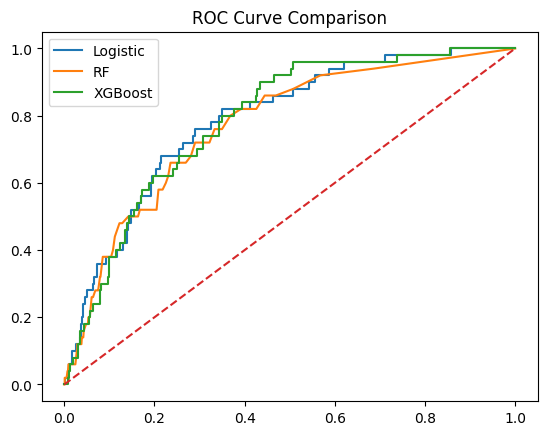

In [15]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)

plt.plot(fpr_lr, tpr_lr, label="Logistic")
plt.plot(fpr_rf, tpr_rf, label="RF")
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve Comparison")
plt.show()

## Threshold Tuning

The default threshold of 0.5 may not be optimal in healthcare. Lowering the threshold improves recall and identifies more high-risk patients.

In [16]:
threshold = 0.3
y_pred = (xgb_probs > threshold).astype(int)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.93      0.94       972
           1       0.15      0.24      0.18        50

    accuracy                           0.89      1022
   macro avg       0.55      0.58      0.56      1022
weighted avg       0.92      0.89      0.91      1022



# Feature importance

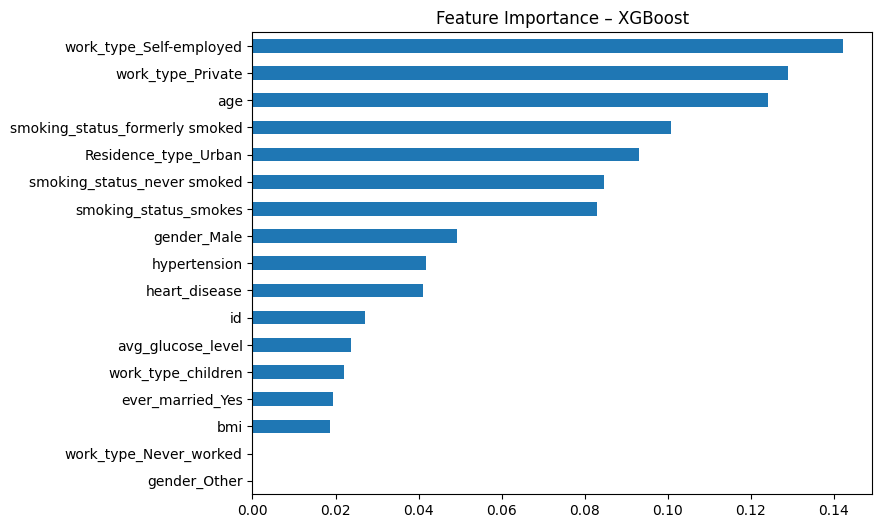

In [17]:
feat_importances = pd.Series(xgb.feature_importances_, index=X.columns)
feat_importances.sort_values().plot(kind="barh", figsize=(8,6))
plt.title("Feature Importance – XGBoost")
plt.show()

# Model comparison

In [18]:
# Logistic predictions
lr_pred = lr.predict(X_test_scaled)

# Random Forest predictions
rf_pred = rf.predict(X_test)

# XGBoost predictions
xgb_pred = xgb.predict(X_test)

# Build comparison table
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    
    "ROC AUC": [
        roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1]),
        roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1])
    ],
    
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred)
    ],
    
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],
    
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ]
})

comparison

,Model,ROC AUC,Precision,Recall,F1 Score
0,Logistic Regression,0.786996,0.141892,0.42,0.212121
1,Random Forest,0.769774,0.161290,0.20,0.178571
2,XGBoost,0.786379,0.153846,0.12,0.134831


# Stability of Results

In [19]:
cv_scores = cross_val_score(
    xgb, X_train_smote, y_train_smote,
    cv=5,
    scoring="roc_auc"
)

print("CV AUC scores:", cv_scores)
print("Mean CV AUC:", cv_scores.mean())

CV AUC scores: [0.96842144 0.99725418 0.99782747 0.99771714 0.99795536]
Mean CV AUC: 0.991835116475781


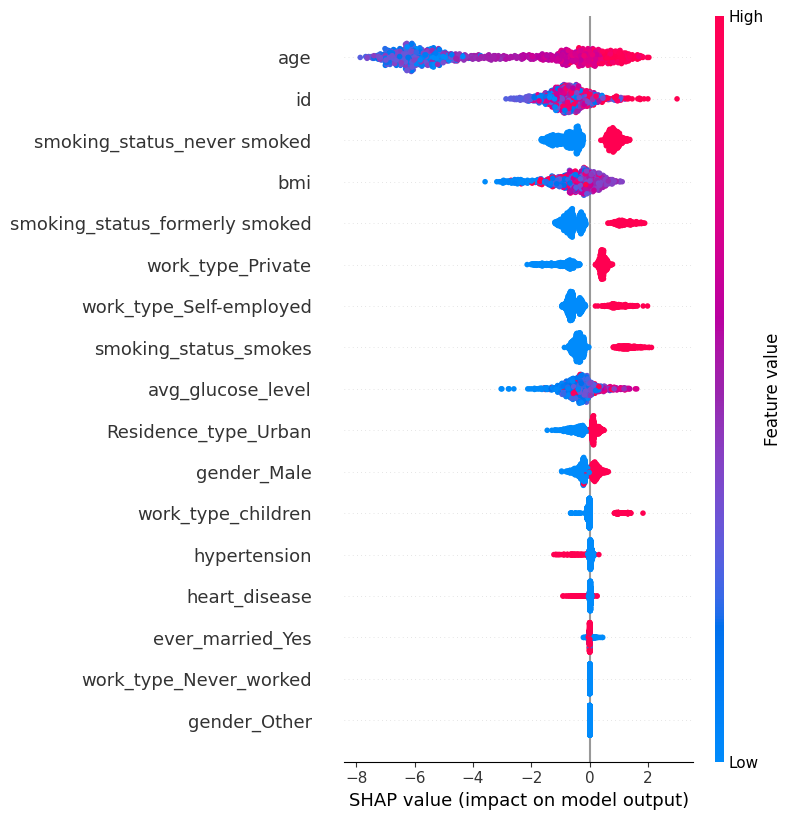

In [19]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

## Discussion

The modeling results highlight important trade-offs between predictive performance and clinical usefulness in stroke risk prediction. While all models achieved similar ROC AUC values (~0.78), the precision and recall analysis revealed significant differences in the ability to identify high-risk patients.

Logistic Regression demonstrated the highest recall (42%), indicating a stronger ability to detect stroke cases compared to Random Forest and XGBoost. However, this came at the cost of lower precision, suggesting a higher number of false positives. In healthcare settings, this trade-off is often acceptable, as early identification of high-risk patients is generally prioritized over minimizing false alarms.

Tree-based models such as Random Forest and XGBoost showed slightly better precision but substantially lower recall. This suggests that while these models are more conservative in predicting stroke, they may fail to identify many at-risk individuals. For preventive healthcare applications, this limitation is critical, as missed stroke cases may result in delayed intervention.

SHAP analysis provided interpretability and clinical insight into model predictions. Age emerged as the most influential predictor, consistent with established medical literature. Additional key contributors included smoking status, BMI, glucose levels, and work type, which may act as proxies for lifestyle and socioeconomic factors.

Interestingly, hypertension and heart disease, while clinically significant, showed moderate importance in this dataset. This may be due to correlations with age and other risk factors. The findings reinforce the importance of both clinical and behavioral factors in stroke risk assessment.

Overall, the results suggest that simpler, interpretable models such as Logistic Regression may be more suitable for healthcare decision support systems, particularly when transparency and early detection are priorities.

Future work may include:

* Hyperparameter tuning
* Calibration
* Deep learning approaches
* Integration with electronic health records


## Conclusion

This study demonstrates the potential of machine learning models to support early stroke risk prediction using demographic, lifestyle, and clinical features. While model accuracy and ROC AUC were comparable across methods, evaluation using precision and recall revealed that Logistic Regression offered the best balance for identifying high-risk patients.

Model interpretability through SHAP further improved trust and transparency, highlighting key risk factors such as age, glucose levels, smoking behavior, and lifestyle indicators. These insights can help clinicians better understand model predictions and support preventive decision-making.

Despite promising results, several challenges remain. The dataset is highly imbalanced, and recall remains moderate, indicating the need for improved detection of stroke cases. Future work should focus on:

Threshold optimization to improve recall

Hyperparameter tuning and ensemble methods

Model calibration for clinical deployment

Integration of longitudinal and electronic health record (EHR) data

Deployment of interpretable and real-time predictive systems

With further refinement, such models could assist healthcare providers in early intervention, personalized risk assessment, and population-level stroke prevention strategies.


In [20]:
import joblib

joblib.dump(lr, "stroke_model.pkl")

['stroke_model.pkl']

In [21]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [22]:
joblib.dump(X.columns, "model_columns.pkl")

['model_columns.pkl']